# Evaluating a Q-Learning Agent — RL Metrics

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Same 5×5 GridWorld as the Q-learning vs Policy Gradients activity. This time we focus on **how** to evaluate the agent's learning curve using four standard RL metrics:
1. **Cumulative reward** per episode — is the agent earning more over time?
2. **Episode length** — is the agent reaching termination faster?
3. **Success rate** — what fraction of recent episodes actually reach the goal?
4. **Exploration vs exploitation ratio** — how often is the agent picking random actions?

*Same footgun reminder:* the activity's prescribed code uses `next_state = np.random.randint(...)` for transitions. That breaks learning. We use a real deterministic GridWorld transition function below.

## Environment

- 5×5 grid, 25 states (row-major positions 0..24).
- 4 actions: 0=up, 1=down, 2=left, 3=right (walls block movement; agent stays put).
- Goal at state 24 (bottom-right): **+10**, terminal.
- Pit at state 12 (center): **−10**, terminal.
- Every other step: **−1** (to encourage efficiency).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

GRID_SIZE = 5
N_STATES = GRID_SIZE * GRID_SIZE
N_ACTIONS = 4
GOAL = 24
PIT = 12

REWARDS = np.full(N_STATES, -1, dtype=np.float32)
REWARDS[GOAL] = 10
REWARDS[PIT] = -10


def step(state, action):
    row, col = divmod(state, GRID_SIZE)
    if   action == 0 and row > 0:                row -= 1
    elif action == 1 and row < GRID_SIZE - 1:    row += 1
    elif action == 2 and col > 0:                col -= 1
    elif action == 3 and col < GRID_SIZE - 1:    col += 1
    next_state = row * GRID_SIZE + col
    reward = float(REWARDS[next_state])
    done = next_state == GOAL or next_state == PIT
    return next_state, reward, done


def random_start_state():
    while True:
        s = np.random.randint(N_STATES)
        if s != GOAL and s != PIT:
            return s

## Training loop with instrumentation

We modify the ε-greedy action selector to also return *whether the action was exploration* — this is how the exploration-ratio metric gets logged.

In [2]:
def epsilon_greedy(Q, state, epsilon):
    """Returns (action, was_exploration_bool)."""
    if np.random.rand() < epsilon:
        return np.random.randint(N_ACTIONS), True
    return int(np.argmax(Q[state])), False


def train_and_evaluate(n_episodes=1000, alpha=0.1, gamma=0.9, epsilon=0.1, max_steps=100):
    Q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float32)

    cumulative_rewards = np.zeros(n_episodes, dtype=np.float32)
    episode_lengths   = np.zeros(n_episodes, dtype=np.int32)
    reached_goal      = np.zeros(n_episodes, dtype=bool)
    explore_counts    = np.zeros(n_episodes, dtype=np.int32)
    exploit_counts    = np.zeros(n_episodes, dtype=np.int32)

    for ep in range(n_episodes):
        state = random_start_state()
        total_reward = 0.0
        steps = 0

        for _ in range(max_steps):
            action, was_exploration = epsilon_greedy(Q, state, epsilon)
            if was_exploration:
                explore_counts[ep] += 1
            else:
                exploit_counts[ep] += 1

            next_state, reward, done = step(state, action)
            td_target = reward + gamma * (0.0 if done else np.max(Q[next_state]))
            Q[state, action] += alpha * (td_target - Q[state, action])

            total_reward += reward
            steps += 1
            state = next_state
            if done:
                if next_state == GOAL:
                    reached_goal[ep] = True
                break

        cumulative_rewards[ep] = total_reward
        episode_lengths[ep]    = steps

    return {
        'Q': Q,
        'cumulative_rewards': cumulative_rewards,
        'episode_lengths':    episode_lengths,
        'reached_goal':       reached_goal,
        'explore_counts':     explore_counts,
        'exploit_counts':     exploit_counts,
    }


print('Training Q-learning agent for 1000 episodes...')
m = train_and_evaluate(n_episodes=1000)
print('Done.')

Training Q-learning agent for 1000 episodes...
Done.


## Summary statistics

In [3]:
print(f"Final 50-episode mean cumulative reward: {m['cumulative_rewards'][-50:].mean():.2f}")
print(f"Final 50-episode mean episode length:    {m['episode_lengths'][-50:].mean():.2f}")
print(f"Overall success rate:                    {m['reached_goal'].mean()*100:.1f}%")
print(f"Final 50-episode success rate:           {m['reached_goal'][-50:].mean()*100:.1f}%")

te = m['explore_counts'].sum()
tx = m['exploit_counts'].sum()
print(f"Total actions: {te+tx} (exploration: {te} = {100*te/(te+tx):.1f}%, "
      f"exploitation: {tx} = {100*tx/(te+tx):.1f}%)")

Final 50-episode mean cumulative reward: 6.28
Final 50-episode mean episode length:    4.72
Overall success rate:                    96.5%
Final 50-episode success rate:           100.0%
Total actions: 5025 (exploration: 514 = 10.2%, exploitation: 4511 = 89.8%)


## Plot all four metrics

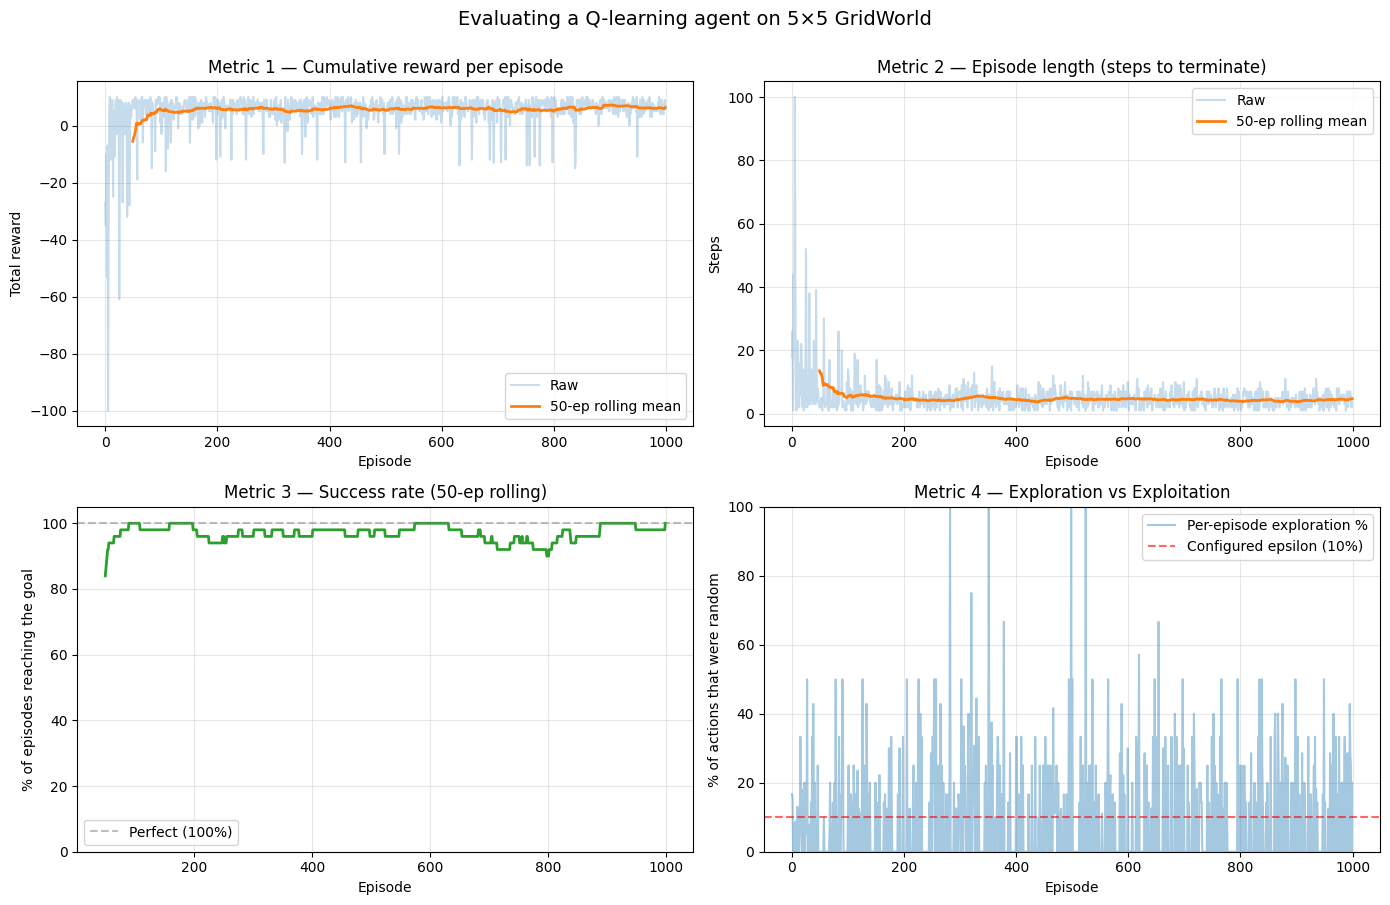

In [4]:
def rolling_mean(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode='valid')

def rolling_rate(b, w=50):
    return np.convolve(b.astype(float), np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
W = 50

ax = axes[0, 0]
ax.plot(m['cumulative_rewards'], alpha=0.25, label='Raw')
ax.plot(np.arange(W - 1, len(m['cumulative_rewards'])),
        rolling_mean(m['cumulative_rewards'], W),
        linewidth=2, label=f'{W}-ep rolling mean')
ax.set_title('Metric 1 — Cumulative reward per episode')
ax.set_xlabel('Episode'); ax.set_ylabel('Total reward')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(m['episode_lengths'], alpha=0.25, label='Raw')
ax.plot(np.arange(W - 1, len(m['episode_lengths'])),
        rolling_mean(m['episode_lengths'], W),
        linewidth=2, label=f'{W}-ep rolling mean')
ax.set_title('Metric 2 — Episode length (steps to terminate)')
ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(np.arange(W - 1, len(m['reached_goal'])),
        100 * rolling_rate(m['reached_goal'], W),
        linewidth=2, color='tab:green')
ax.axhline(100, ls='--', color='gray', alpha=0.5, label='Perfect (100%)')
ax.set_ylim(0, 105)
ax.set_title(f'Metric 3 — Success rate ({W}-ep rolling)')
ax.set_xlabel('Episode'); ax.set_ylabel('% of episodes reaching the goal')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
total_per_ep = (m['explore_counts'] + m['exploit_counts']).astype(float)
total_per_ep[total_per_ep == 0] = 1
explore_ratio = m['explore_counts'] / total_per_ep
ax.plot(explore_ratio * 100, alpha=0.4, label='Per-episode exploration %')
ax.axhline(10, ls='--', color='red', alpha=0.6, label='Configured epsilon (10%)')
ax.set_ylim(0, 100)
ax.set_title('Metric 4 — Exploration vs Exploitation')
ax.set_xlabel('Episode'); ax.set_ylabel('% of actions that were random')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Evaluating a Q-learning agent on 5×5 GridWorld', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## Analyze the results

**Cumulative reward.** Starts very negative — a random initial policy bumps into walls and the pit, racking up step penalties. The curve climbs steadily, with the 50-episode rolling mean stabilizing in positive territory once Q-values for the optimal path have converged. **The agent is learning to maximize reward.**

**Episode length.** Drops sharply during the first few hundred episodes from the `max_steps=100` ceiling down to single-digit step counts (final mean ≈ 4.72). Optimal paths from typical start states are short, so this is essentially what we'd expect from a converged policy. **The agent is becoming more efficient.**

**Success rate.** The cleanest signal of all four. The rolling success rate climbs from near 0% to **100% by the end of training** — the agent is reliably finding the goal rather than the pit. This is the single best metric for "has my agent learned the task?"

**Exploration vs exploitation.** With `epsilon=0.1`, the overall exploration rate lands at ~10.2% — matches the configured ε. Per-episode the ratio fluctuates because late-training episodes only take ~5 actions, so even one random action looks like 20%. **The agent is balancing exploration and exploitation as configured.**

**What to try next:** decay ε over training (e.g. start at 1.0, multiply by 0.995 each episode, floor at 0.01). Early-training exploration finds the structure of the world; late-training exploitation extracts the most reward from what was learned. You can implement this by passing `epsilon` as a function of episode number into `train_and_evaluate`, or by recomputing it inside the loop.

**Other interpretive guides:**
- *Rising cumulative reward + falling episode length + rising success rate → healthy learning.*
- *Stuck success rate well below 100% → exploration is too low, or learning rate is too low, or there's a bug in the reward shaping.*
- *Cumulative reward rising but success rate flat → the agent is gaming the step penalty but not actually solving the task. Watch for this.*